## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importing the Dataset

In [2]:
customer_data = pd.read_csv('D:\Churn_Modelling.csv')

# Droping the ineffective columns
dataset = customer_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)
dataset

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Removing the outliers

In [3]:
dataset.drop(dataset[dataset['CreditScore'] <= 359].index, inplace = True)

dataset.drop(dataset[dataset['Age'] >= 71].index, inplace = True)

dataset.drop(dataset[dataset['NumOfProducts'] >= 4].index, inplace = True)

# Shape of Data after removing the outliers
print("Shape of Data after removing outliers: {}".format(dataset.shape))

Shape of Data after removing outliers: (9799, 11)


# Features Engineering

In [4]:
dataset['BalanceSalary'] = dataset.Balance / dataset.EstimatedSalary
dataset['TenureAge'] = dataset.Tenure / (dataset.Age)
dataset['ScoreAge'] = dataset.CreditScore / (dataset.Age)

dataset['tenure_age'] = dataset.Tenure / (dataset.Age - 17)
dataset['tenure_salary'] = dataset.Tenure / (dataset.EstimatedSalary)
dataset['score_age'] = dataset.CreditScore / (dataset.Age - 17)
dataset['score_salary'] = dataset.CreditScore / (dataset.EstimatedSalary)

dataset["newAge"] = dataset["Age"] - dataset["Tenure"]
dataset["newCreditScore"] = pd.qcut(dataset['CreditScore'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["AgeScore"] = pd.qcut(dataset['Age'], 8, labels = [1, 2, 3, 4, 5, 6, 7, 8])
dataset["BalanceScore"] = pd.qcut(dataset['Balance'].rank(method = "first"), 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["SalaryScore"] = pd.qcut(dataset['EstimatedSalary'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["newEstimatedSalary"] = dataset["EstimatedSalary"] / 12 

dataset['score_balance'] = dataset.Balance / (dataset.CreditScore)
dataset['age_balance'] = dataset.Balance / (dataset.Age)
dataset['balance_salary'] = dataset.Balance / (dataset.EstimatedSalary)
dataset['age_hascrcard'] = dataset.HasCrCard / (dataset.Age)

In [5]:
def product_utilization_rate_by_year(row):
    number_of_products = row.NumOfProducts
    tenure = row.Tenure
    
    if number_of_products == 0:
        return 0
    if tenure == 0:
        return number_of_products
    
    rate = number_of_products / tenure
    return rate

def product_utilization_rate_by_salary(row):
    number_of_products = row.NumOfProducts
    estimated_salary = row.EstimatedSalary
    
    if number_of_products == 0:
        return 0
    
    rate = number_of_products / estimated_salary
    return rate

def countries_monthly_average_salaries(row):
    fr = 3696    
    de = 4740
    sp = 2257
    salary = row.EstimatedSalary / 12
    country = row.Geography
    
    if country == "Germany":
        return salary / de
    elif country == "France":
        return salary / fr
    elif country == "Spain": 
        return salary / sp

In [ ]:
def feature_engineering(cus, is_show_graph = False):
    df_fe = dataset.copy()
    
    # product usage rate by year
    df_fe = df_fe.assign(product_utilization_rate_by_year = df_fe.apply(lambda x: product_utilization_rate_by_year(x), axis = 1))
    
    # product usage rate by estimated salary
    df_fe = df_fe.assign(product_utilization_rate_by_salary = df_fe.apply(lambda x: product_utilization_rate_by_salary(x), axis = 1)) 
    
    # average monthly salary according to countries
    df_fe = df_fe.assign(countries_monthly_average_salaries = df_fe.apply(lambda x: countries_monthly_average_salaries(x), axis = 1))
    
    return df_fe

In [7]:
df_fe = feature_engineering(dataset)
df_fe

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,BalanceScore,SalaryScore,newEstimatedSalary,score_balance,age_balance,balance_salary,age_hascrcard,product_utilization_rate_by_year,product_utilization_rate_by_salary,countries_monthly_average_salaries
0,619,France,Female,42,2,0.00,1,1,1,101348.88,...,1,6,8445.740000,0.000000,0.000000,0.000000,0.023810,0.500000,0.000010,2.285103
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,...,5,6,9378.548333,137.841875,2044.094146,0.744677,0.000000,1.000000,0.000009,4.155316
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,...,10,6,9494.297500,318.049402,3801.447619,1.401375,0.023810,0.375000,0.000026,2.568803
3,699,France,Female,39,1,0.00,2,0,0,93826.63,...,1,5,7818.885833,0.000000,0.000000,0.000000,0.000000,2.000000,0.000021,2.115499
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,...,8,4,6590.341667,147.659788,2918.856279,1.587055,0.023256,0.500000,0.000013,2.919956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,...,4,5,8022.553333,0.000000,0.000000,0.000000,0.025641,0.400000,0.000021,2.170604
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,...,4,6,8474.980833,111.181415,1639.131714,0.564108,0.028571,0.100000,0.000010,2.293014
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,...,4,3,3507.131667,0.000000,0.000000,0.000000,0.000000,0.142857,0.000024,0.948899
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,...,5,5,7740.710000,97.247811,1787.507381,0.808230,0.023810,0.666667,0.000022,1.633061


In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Converting inputs to numeric values
encoder = LabelEncoder()
df_fe["Geography"] = encoder.fit_transform(df_fe["Geography"])
df_fe["Gender"] = encoder.fit_transform(df_fe["Gender"])

# Encoding categorical data
df_fe = df_fe.drop(['Geography', 'Gender'], axis = 1)
Geography = pd.get_dummies(dataset.Geography, drop_first = True)
Gender = pd.get_dummies(dataset.Gender).iloc[:, 0:]

In [9]:
# Data merging
df_fe = pd.concat([df_fe, Geography, Gender], axis = 1)
df_fe

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalary,...,age_balance,balance_salary,age_hascrcard,product_utilization_rate_by_year,product_utilization_rate_by_salary,countries_monthly_average_salaries,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,...,0.000000,0.000000,0.023810,0.500000,0.000010,2.285103,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,...,2044.094146,0.744677,0.000000,1.000000,0.000009,4.155316,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,...,3801.447619,1.401375,0.023810,0.375000,0.000026,2.568803,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,...,0.000000,0.000000,0.000000,2.000000,0.000021,2.115499,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587055,...,2918.856279,1.587055,0.023256,0.500000,0.000013,2.919956,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,...,0.000000,0.000000,0.025641,0.400000,0.000021,2.170604,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0.564108,...,1639.131714,0.564108,0.028571,0.100000,0.000010,2.293014,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,...,0.000000,0.000000,0.000000,0.142857,0.000024,0.948899,0,0,1,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.808230,...,1787.507381,0.808230,0.023810,0.666667,0.000022,1.633061,1,0,0,1


### Segregating input and output variables and Scaling data

In [10]:
from sklearn.preprocessing import StandardScaler

# Data inputs
X = df_fe.drop(['Exited'], axis = 1)
m = X

# Feature Scaling
sc = StandardScaler()
X = sc.fit_transform(X)
X = pd.DataFrame(X)
X.columns = m.columns

# Data outputs
Y = df_fe['Exited']

### Data Devision

In [11]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7839, 32) (1960, 32) (7839,) (1960,)


# Sampling

In [12]:
from collections import Counter
from imblearn.over_sampling import SMOTEN

sm = SMOTEN()
X_smot_train, Y_smot_train = sm.fit_resample(X_train, y_train)
X_smot_test, Y_smot_test = sm.fit_resample(X_test, y_test)

print('Original dataset shape(Train): ', Counter(y_train))
print('Resampled dataset shape(Train): ', Counter(Y_smot_train))
print('\nOriginal dataset shape(Test): ', Counter(y_test))
print('Resampled dataset shape(Test): ', Counter(Y_smot_test))

Original dataset shape(Train):  Counter({0: 6256, 1: 1583})
Resampled dataset shape(Train):  Counter({0: 6256, 1: 6256})

Original dataset shape(Test):  Counter({0: 1585, 1: 375})
Resampled dataset shape(Test):  Counter({0: 1585, 1: 1585})


# Model Fitting

In [13]:
# Import different models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scoring functions
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

# Support functions
from sklearn.model_selection import KFold, cross_val_score

## Support Vector Machine

### Polynomial kernel

In [14]:
# Fit SVM with POLY Kernel
svm_poly = SVC(kernel = 'poly', probability = True)

# Fitting the model with training data 
svm_poly.fit(X_smot_train, Y_smot_train)

y_pred_poly = svm_poly.predict(X_smot_test)

accuracy_poly = accuracy_score(Y_smot_test, y_pred_poly)

print(confusion_matrix(Y_smot_test, y_pred_poly))
print(classification_report(Y_smot_test, y_pred_poly, digits = 4))
print("Accuracy score of Support Vector Machine: ", accuracy_poly)

[[1541   44]
 [ 252 1333]]
              precision    recall  f1-score   support

           0     0.8595    0.9722    0.9124      1585
           1     0.9680    0.8410    0.9001      1585

    accuracy                         0.9066      3170
   macro avg     0.9137    0.9066    0.9062      3170
weighted avg     0.9137    0.9066    0.9062      3170

Accuracy score of Support Vector Machine:  0.9066246056782334


### Radial Basis Function kernel

In [15]:
# Initialization of the SVM
svm_rbf = SVC(kernel = 'rbf' , probability = True)

# Fitting the model with training data 
svm_rbf = svm_rbf.fit(X_smot_train, Y_smot_train)

y_pred_rbf = svm_rbf.predict(X_smot_test)

accuracy_rbf = accuracy_score(Y_smot_test, y_pred_rbf)

print(confusion_matrix(Y_smot_test, y_pred_rbf))
print(classification_report(Y_smot_test, y_pred_rbf, digits = 4))
print("Accuracy score of Support Vector Machine: ", accuracy_rbf)

[[1538   47]
 [ 236 1349]]
              precision    recall  f1-score   support

           0     0.8670    0.9703    0.9157      1585
           1     0.9663    0.8511    0.9051      1585

    accuracy                         0.9107      3170
   macro avg     0.9166    0.9107    0.9104      3170
weighted avg     0.9166    0.9107    0.9104      3170

Accuracy score of Support Vector Machine:  0.9107255520504732


## Logistic Regression

In [16]:
# Initialization of the LR
lr_model = LogisticRegression()

# Fitting the model with training data 
lr_model = lr_model.fit(X_smot_train, Y_smot_train)

y_pred_lr = lr_model.predict(X_smot_test)

accuracy_lr = accuracy_score(Y_smot_test, y_pred_lr)

print(confusion_matrix(Y_smot_test, y_pred_lr))
print(classification_report(Y_smot_test, y_pred_lr, digits = 4))
print("Accuracy score of Logistic Regression: ", accuracy_lr)

[[1453  132]
 [ 244 1341]]
              precision    recall  f1-score   support

           0     0.8562    0.9167    0.8854      1585
           1     0.9104    0.8461    0.8770      1585

    accuracy                         0.8814      3170
   macro avg     0.8833    0.8814    0.8812      3170
weighted avg     0.8833    0.8814    0.8812      3170

Accuracy score of Logistic Regression:  0.8813880126182966


E:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest

In [17]:
# Initialization of the RF
rf_model = RandomForestClassifier()

# Fitting the model with training data 
rf_model = rf_model.fit(X_smot_train, Y_smot_train)

y_pred_rf = rf_model.predict(X_smot_test)

accuracy_rf = accuracy_score(Y_smot_test, y_pred_rf)

print(confusion_matrix(Y_smot_test, y_pred_rf))
print(classification_report(Y_smot_test, y_pred_rf, digits = 4))
print("Accuracy score of Random Forest: ", accuracy_rf)

[[1527   58]
 [ 227 1358]]
              precision    recall  f1-score   support

           0     0.8706    0.9634    0.9146      1585
           1     0.9590    0.8568    0.9050      1585

    accuracy                         0.9101      3170
   macro avg     0.9148    0.9101    0.9098      3170
weighted avg     0.9148    0.9101    0.9098      3170

Accuracy score of Random Forest:  0.9100946372239748


## K-Nearest Neighbors

In [18]:
# Initialization of the KNN
knn_model = KNeighborsClassifier()

# Fitting the model with training data 
knn_model = knn_model.fit(X_smot_train, Y_smot_train)

y_pred_knn = knn_model.predict(X_smot_test)

accuracy_knn = accuracy_score(Y_smot_test, y_pred_knn)

print(confusion_matrix(Y_smot_test, y_pred_knn))
print(classification_report(Y_smot_test, y_pred_knn, digits = 4))
print("Accuracy score of KNeighbors: ", accuracy_knn)

[[1468  117]
 [ 311 1274]]
              precision    recall  f1-score   support

           0     0.8252    0.9262    0.8728      1585
           1     0.9159    0.8038    0.8562      1585

    accuracy                         0.8650      3170
   macro avg     0.8705    0.8650    0.8645      3170
weighted avg     0.8705    0.8650    0.8645      3170

Accuracy score of KNeighbors:  0.8649842271293375


# ROC-AUC

In [19]:
poly_acc = svm_poly.score(X_smot_test, Y_smot_test)
rbf_acc = svm_rbf.score(X_smot_test, Y_smot_test)
lr_acc = lr_model.score(X_smot_test, Y_smot_test)
rf_acc = rf_model.score(X_smot_test, Y_smot_test)
knn_acc = knn_model.score(X_smot_test, Y_smot_test)

In [20]:
auc_svm_poly = roc_auc_score(Y_smot_test, svm_poly.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_svm_rbf = roc_auc_score(Y_smot_test, svm_rbf.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_lr = roc_auc_score(Y_smot_test, lr_model.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_rf = roc_auc_score(Y_smot_test, rf_model.predict_proba(np.array(X_smot_test.values))[:, 1])
auc_knn = roc_auc_score(Y_smot_test, knn_model.predict_proba(np.array(X_smot_test.values))[:, 1])

E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [21]:
models = ['SVM_POLY', 'SVM_RBF', 'Logistic Regression', 'Random Forest', 'K-Nearest Neighbors']
accuracy = [poly_acc, rbf_acc, lr_acc, rf_acc, knn_acc]
roc_auc = [auc_svm_poly, auc_svm_rbf, auc_lr, auc_rf, auc_knn]

d = {'accuracy': accuracy, 'roc_auc': roc_auc}
df_metrics = pd.DataFrame(d, index = models)
df_metrics

,accuracy,roc_auc
SVM_POLY,0.906625,0.953760
SVM_RBF,0.910726,0.956757
Logistic Regression,0.881388,0.940349
Random Forest,0.910095,0.957999
K-Nearest Neighbors,0.864984,0.918016


In [22]:
fpr_svm_poly, tpr_svm_poly, _ = roc_curve(Y_smot_test, svm_poly.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(Y_smot_test, svm_rbf.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_lr, tpr_lr, _ = roc_curve(Y_smot_test, lr_model.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(Y_smot_test, rf_model.predict_proba(np.array(X_smot_test.values))[:, 1])
fpr_knn, tpr_knn, _ = roc_curve(Y_smot_test, knn_model.predict_proba(np.array(X_smot_test.values))[:, 1])

E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
E:\Anaconda\lib\site-packages\sklearn\base.py:445: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


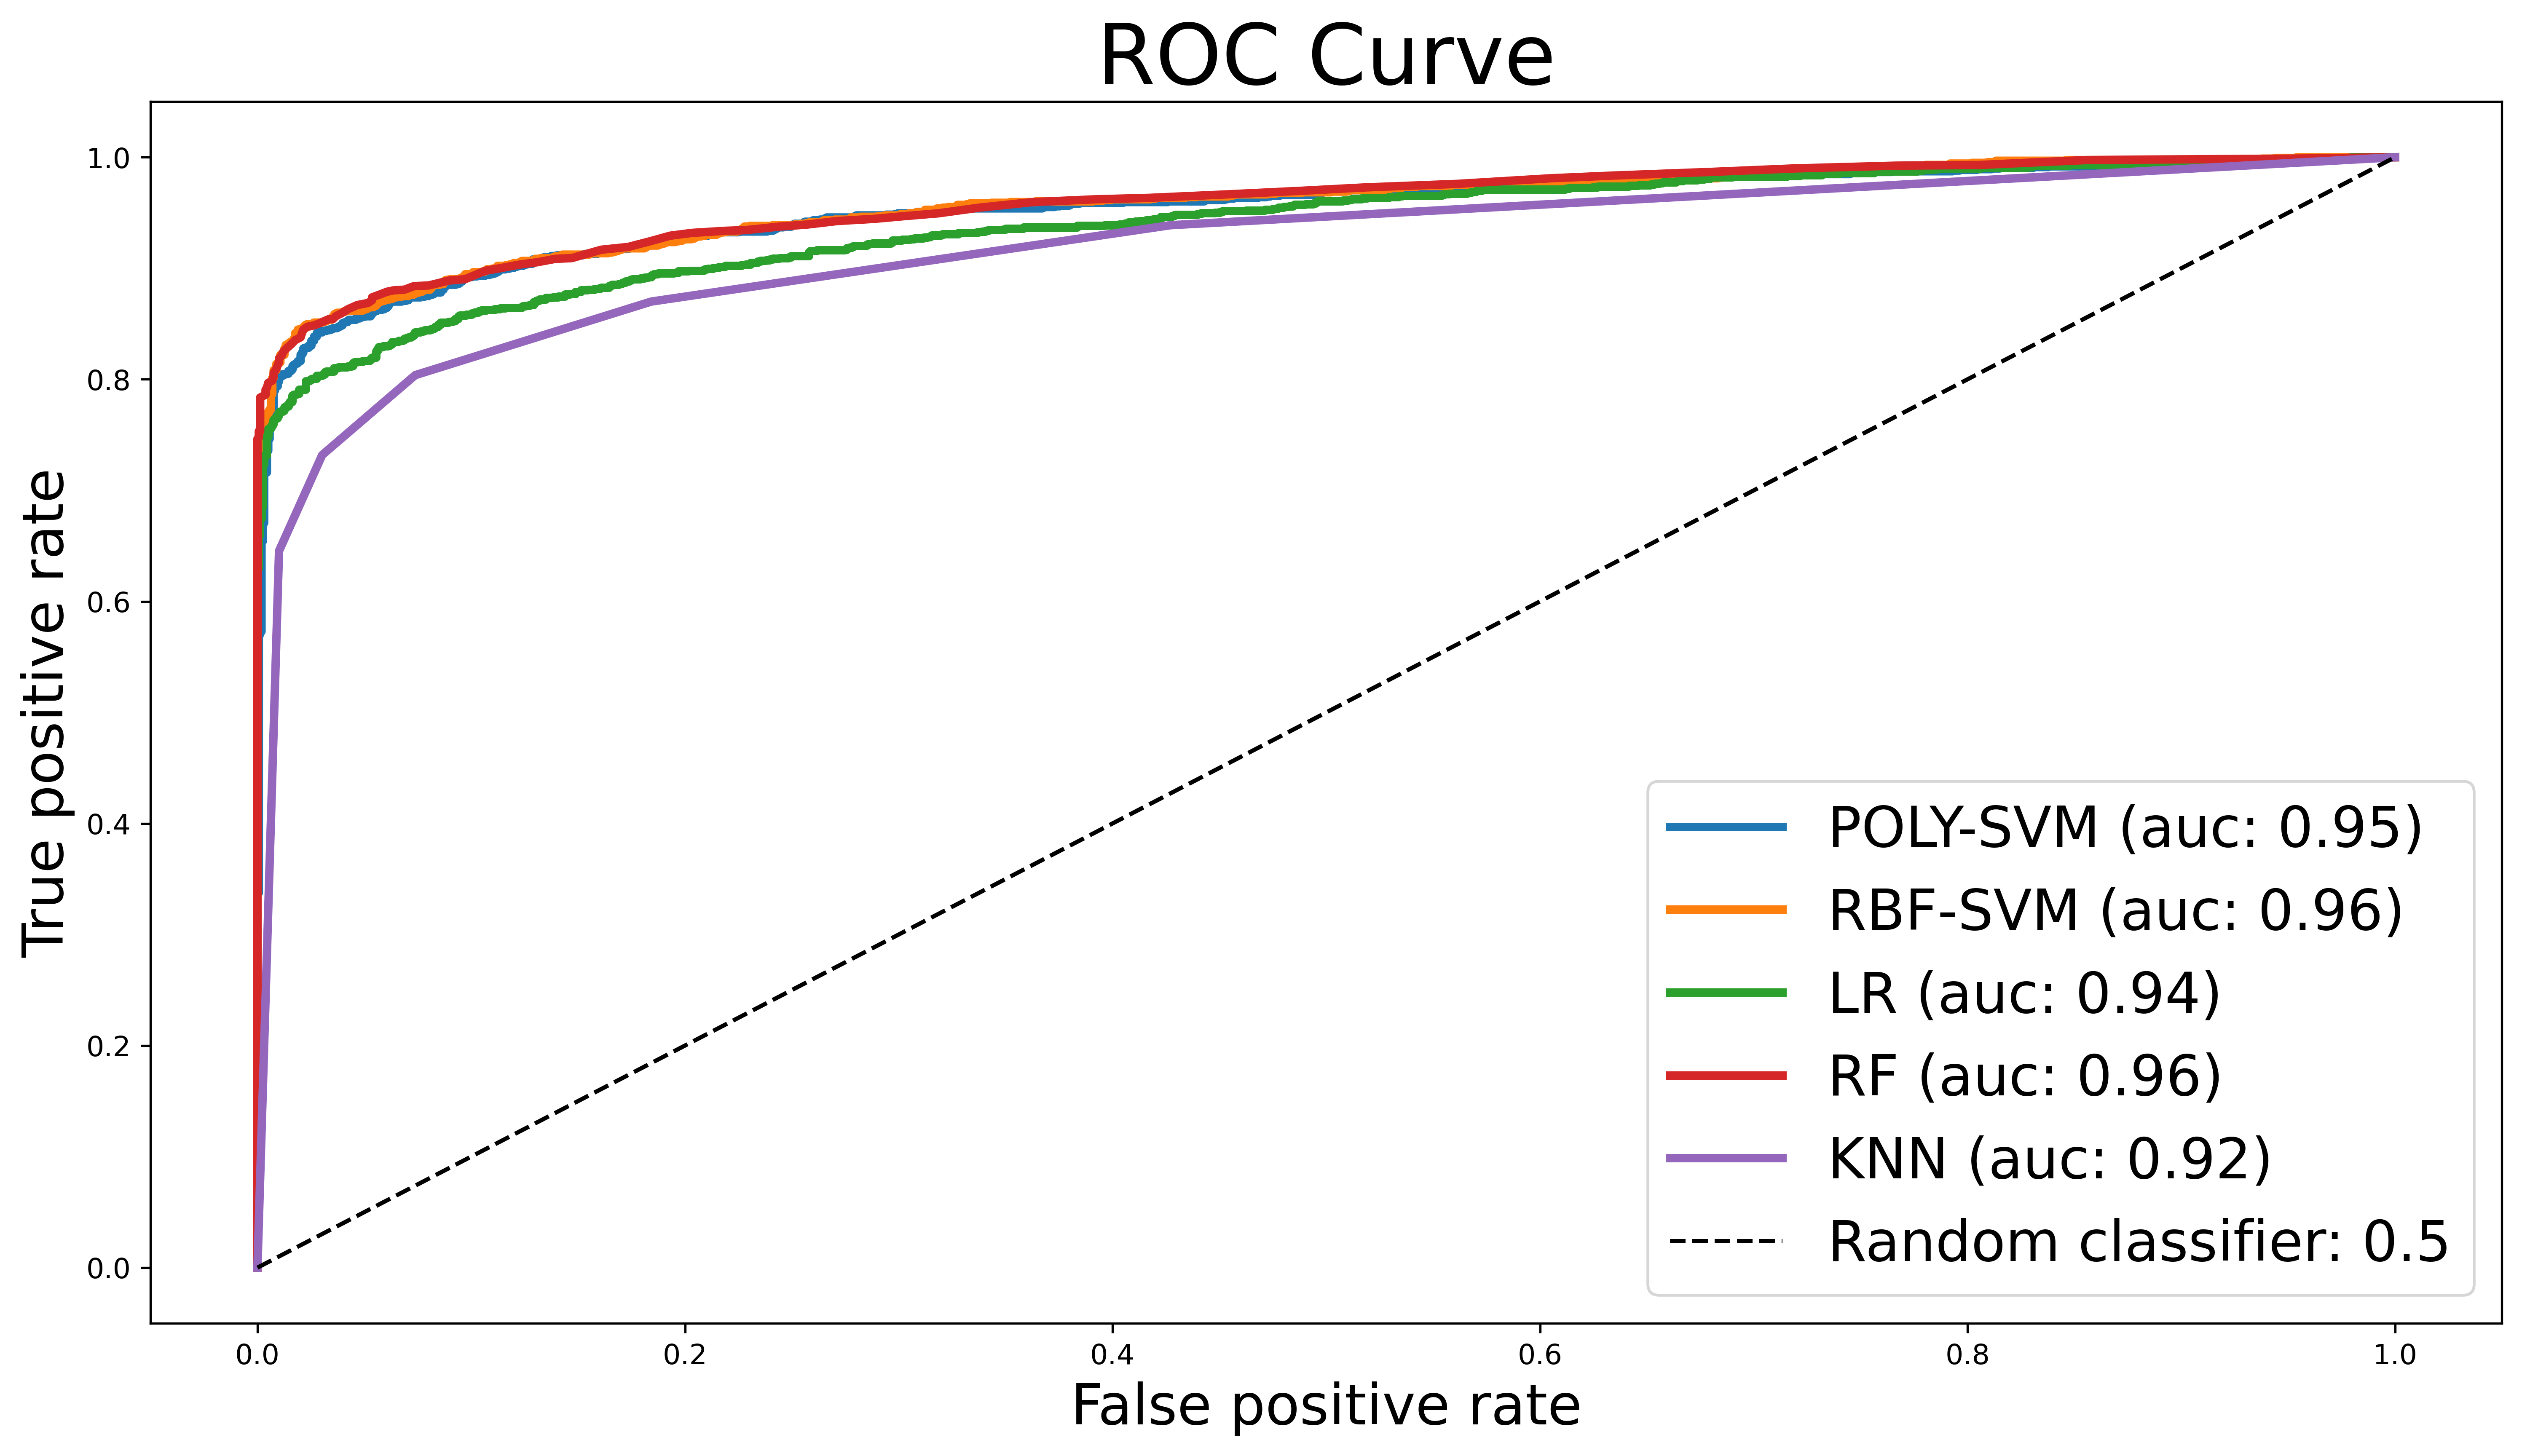

In [23]:
plt.figure(figsize = (15, 8), dpi = 480)
plt.plot(fpr_svm_poly, tpr_svm_poly, label = 'POLY-SVM (auc: {:.2f})'.format(auc_svm_poly), linewidth = 3.0)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, label = 'RBF-SVM (auc: {:.2f})'.format(auc_svm_rbf), linewidth = 3.0)
plt.plot(fpr_lr, tpr_lr, label = 'LR (auc: {:.2f})'.format(auc_lr), linewidth = 3.0)
plt.plot(fpr_rf, tpr_rf, label = 'RF (auc: {:.2f})'.format(auc_rf), linewidth = 3.0)
plt.plot(fpr_knn, tpr_knn, label = 'KNN (auc: {:.2f})'.format(auc_knn), linewidth = 3.0)

plt.plot([0,1], [0,1], 'k--', label = 'Random classifier: 0.5')
plt.xlabel('False positive rate', fontsize = 20)
plt.ylabel('True positive rate', fontsize = 20)
plt.title('ROC Curve', fontsize = 30)
plt.legend(loc = 'best', fontsize = 20)
plt.savefig('ROC_FE,Sample.png')
plt.show()

# AUC plots

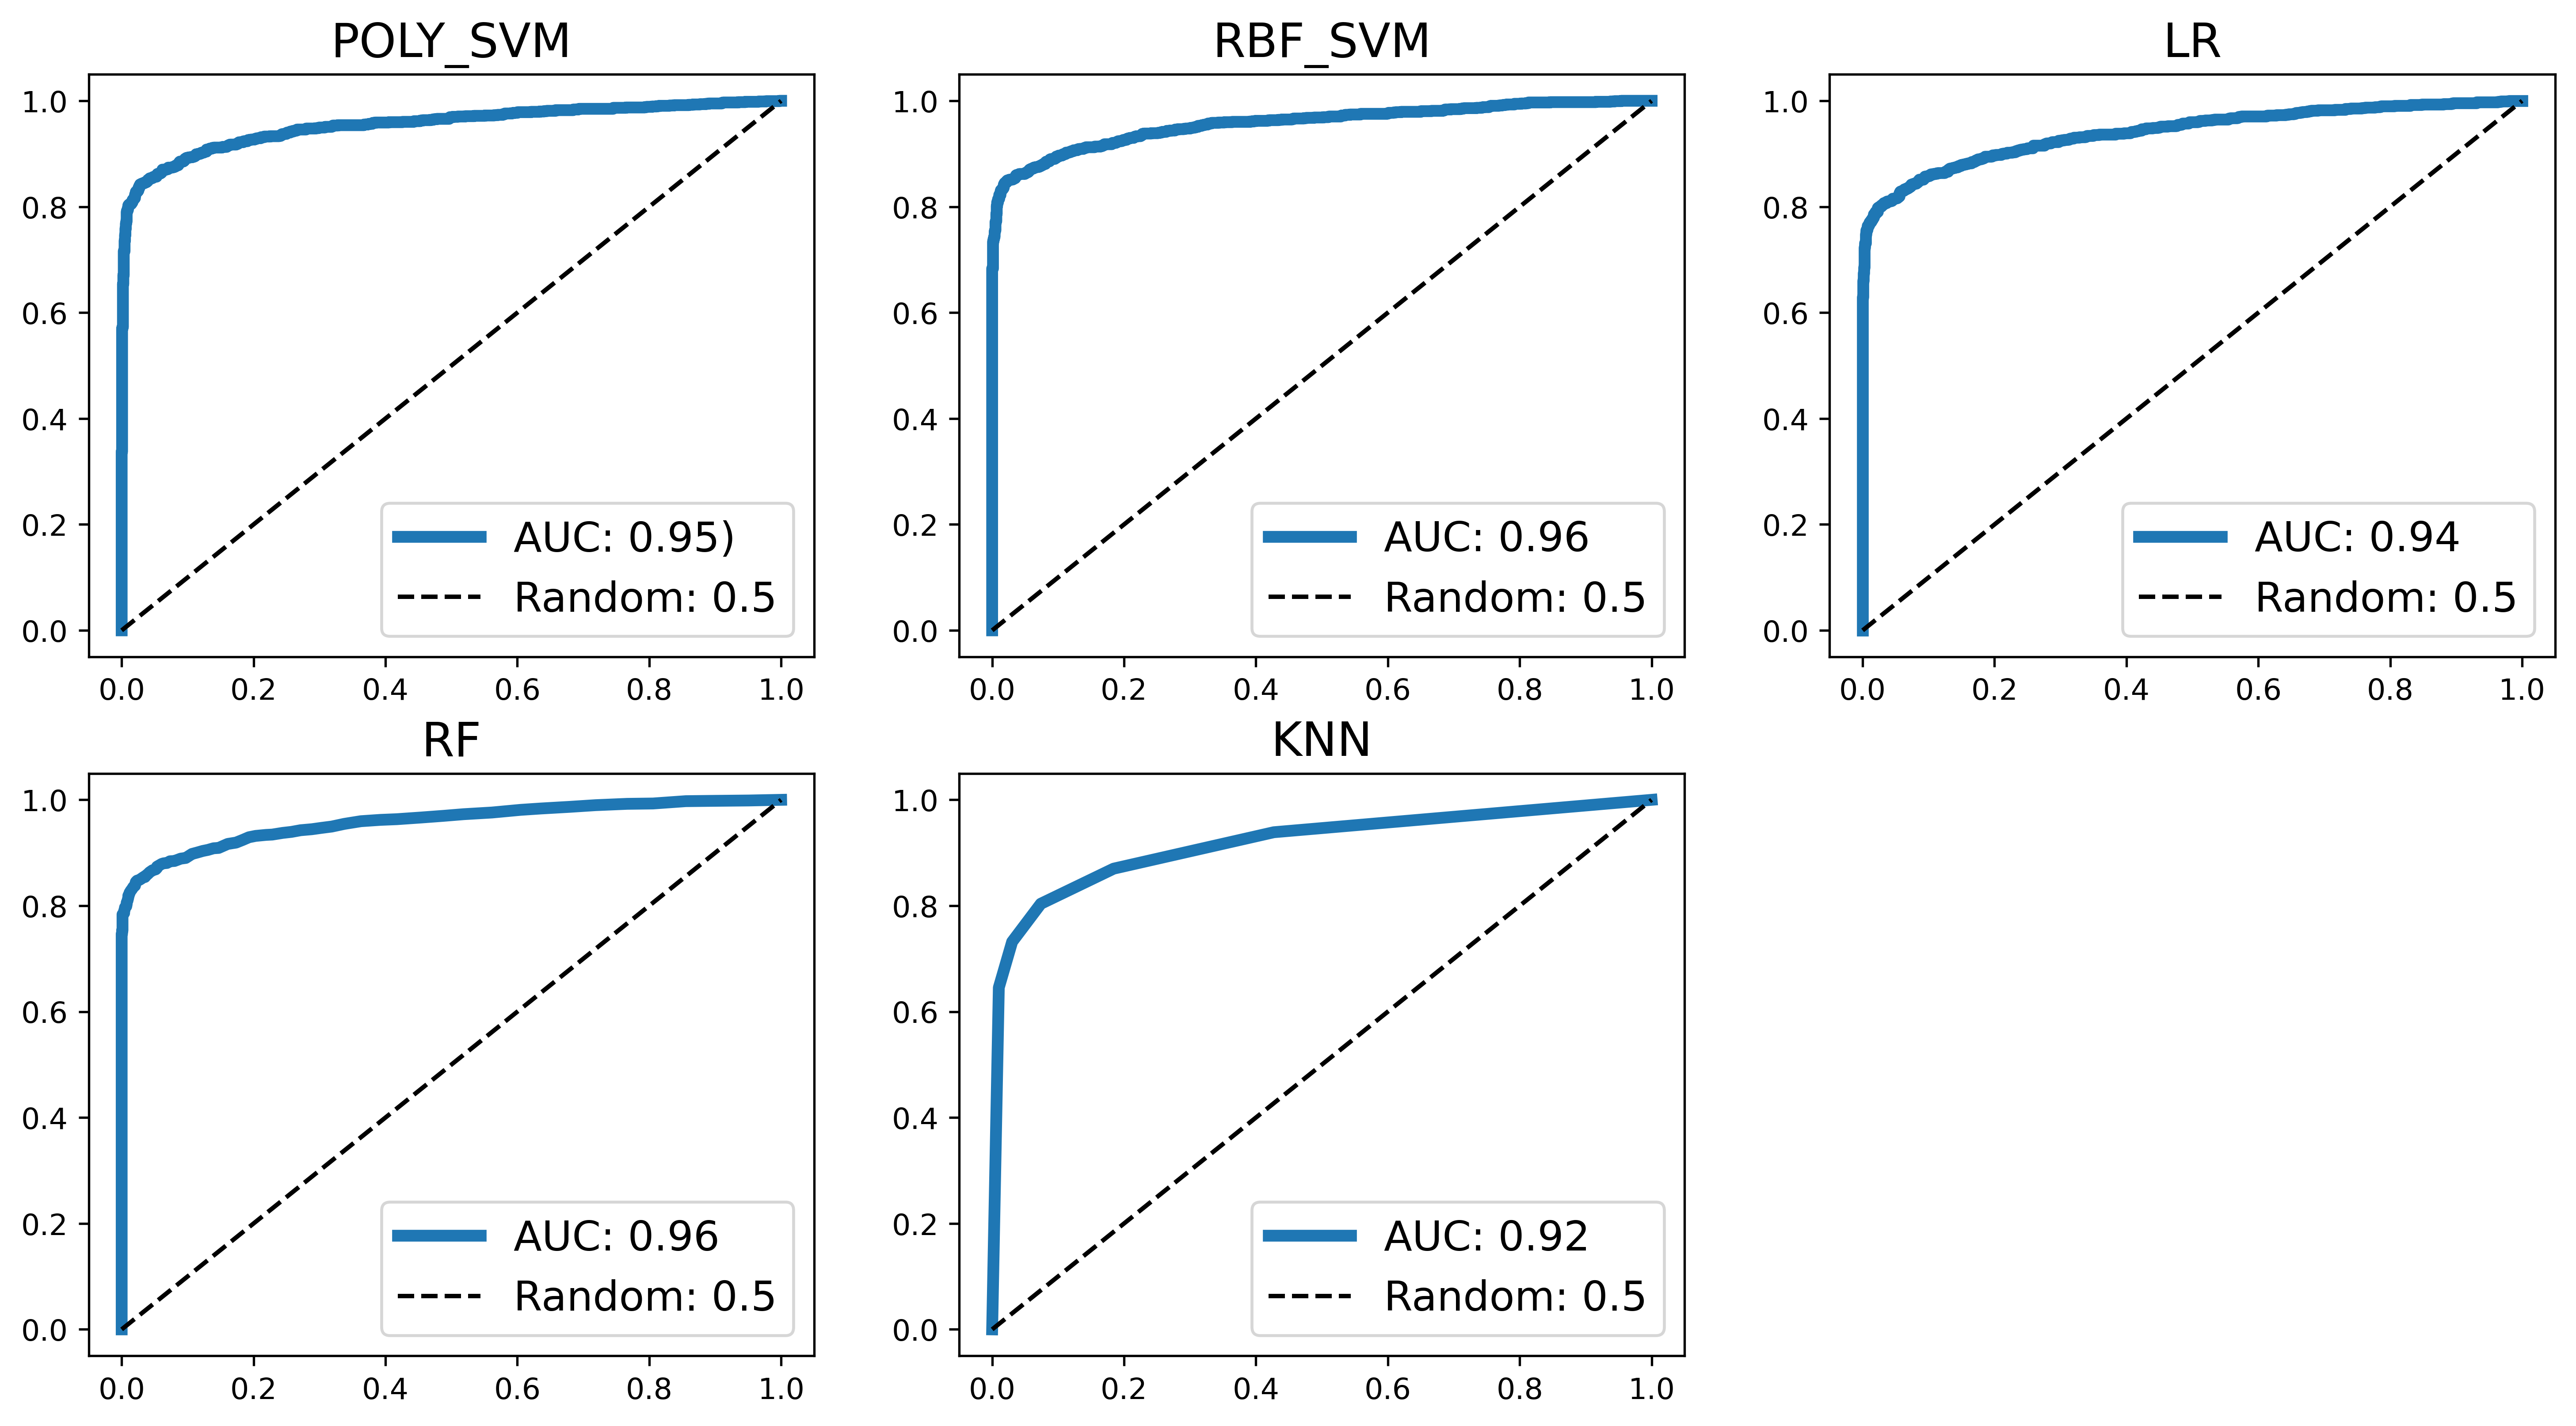

In [24]:
plt.figure(figsize = (15, 8), dpi = 480)

plt.subplot(2, 3, 1)
plt.plot(fpr_svm_poly, tpr_svm_poly, label = 'AUC: {:.2f})'.format(auc_svm_poly), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'best', fontsize = 14)
plt.title('POLY_SVM', fontsize = 16)

plt.subplot(2, 3, 2)
plt.plot(fpr_svm_rbf, tpr_svm_rbf, label = 'AUC: {:.2f}'.format(auc_svm_rbf), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('RBF_SVM', fontsize = 16)

plt.subplot(2, 3, 3)
plt.plot(fpr_lr, tpr_lr, label = 'AUC: {:.2f}'.format(auc_lr), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('LR', fontsize = 16)

plt.subplot(2, 3, 4)
plt.plot(fpr_rf, tpr_rf, label = 'AUC: {:.2f}'.format(auc_rf), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('RF', fontsize = 16)

plt.subplot(2, 3, 5)
plt.plot(fpr_knn, tpr_knn, label = 'AUC: {:.2f}'.format(auc_knn), linewidth = 4.0)
plt.plot([0,1], [0,1], 'k--', label = 'Random: 0.5')
plt.legend(loc = 'lower right', fontsize = 14)
plt.title('KNN', fontsize = 16)

plt.savefig('AUC_FE,Sample.png')
plt.show()

# Grouped bar chart

Text(0, 0.5, 'Value(%)')

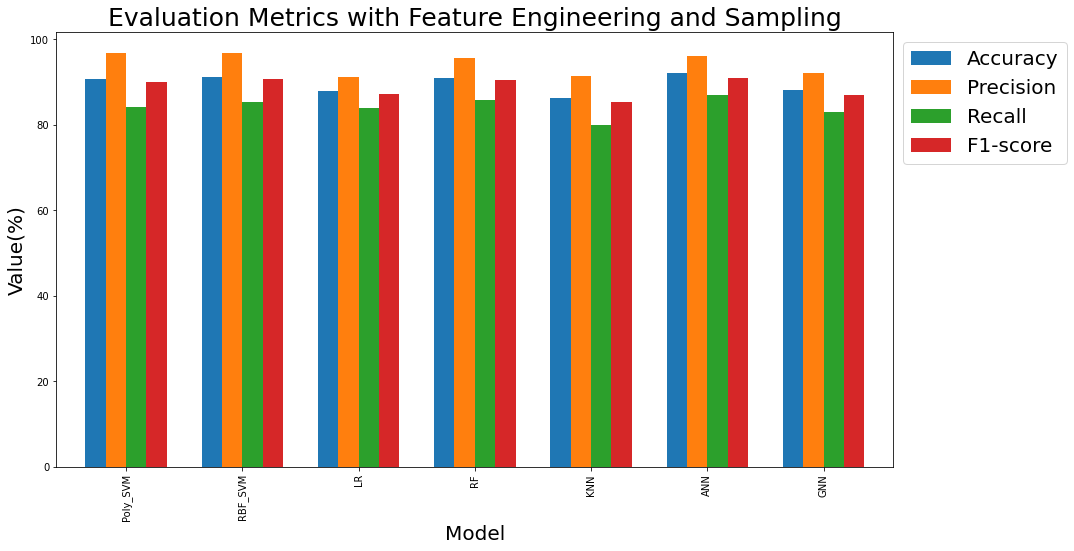

In [25]:
plotdata = pd.DataFrame({"Accuracy":[90.69, 91.19, 87.79, 90.94, 86.21, 92, 88],
                         "Precision":[96.88, 96.71, 91.08, 95.70, 91.41, 96, 92],
                         "Recall":[84.10, 85.30, 83.79, 85.74, 79.94, 87, 83],
                         "F1-score":[90.04, 90.65, 87.28, 90.45, 85.29, 91, 87]},
                        index = ["Poly_SVM", "RBF_SVM", "LR", "RF", "KNN", "ANN", "GNN"])

plotdata.plot(kind = "bar", figsize = (15, 8), legend = False, width = 0.7)
plt.legend(bbox_to_anchor=(1, 1), loc = 'best', fontsize = 20)
plt.title("Evaluation Metrics with Feature Engineering and Sampling", fontsize = 25)
plt.xlabel("Model", fontsize = 20)
plt.ylabel("Value(%)", fontsize = 20)
plt.savefig('EvaluationMetrics_FE,Sampl.png')

# Features Importance

 1) CreditScore                    0.071404
 2) Age                            0.064501
 3) Tenure                         0.059752
 4) Balance                        0.050790
 5) NumOfProducts                  0.048817
 6) HasCrCard                      0.045389
 7) IsActiveMember                 0.039573
 8) EstimatedSalary                0.037094
 9) BalanceSalary                  0.036612
10) TenureAge                      0.036213
11) ScoreAge                       0.036047
12) tenure_age                     0.034181
13) tenure_salary                  0.033817
14) score_age                      0.033317
15) score_salary                   0.032783
16) newAge                         0.032628
17) newCreditScore                 0.032506
18) AgeScore                       0.030633
19) BalanceScore                   0.029636
20) SalaryScore                    0.027725
21) newEstimatedSalary             0.027655
22) score_balance                  0.027045
23) age_balance                 

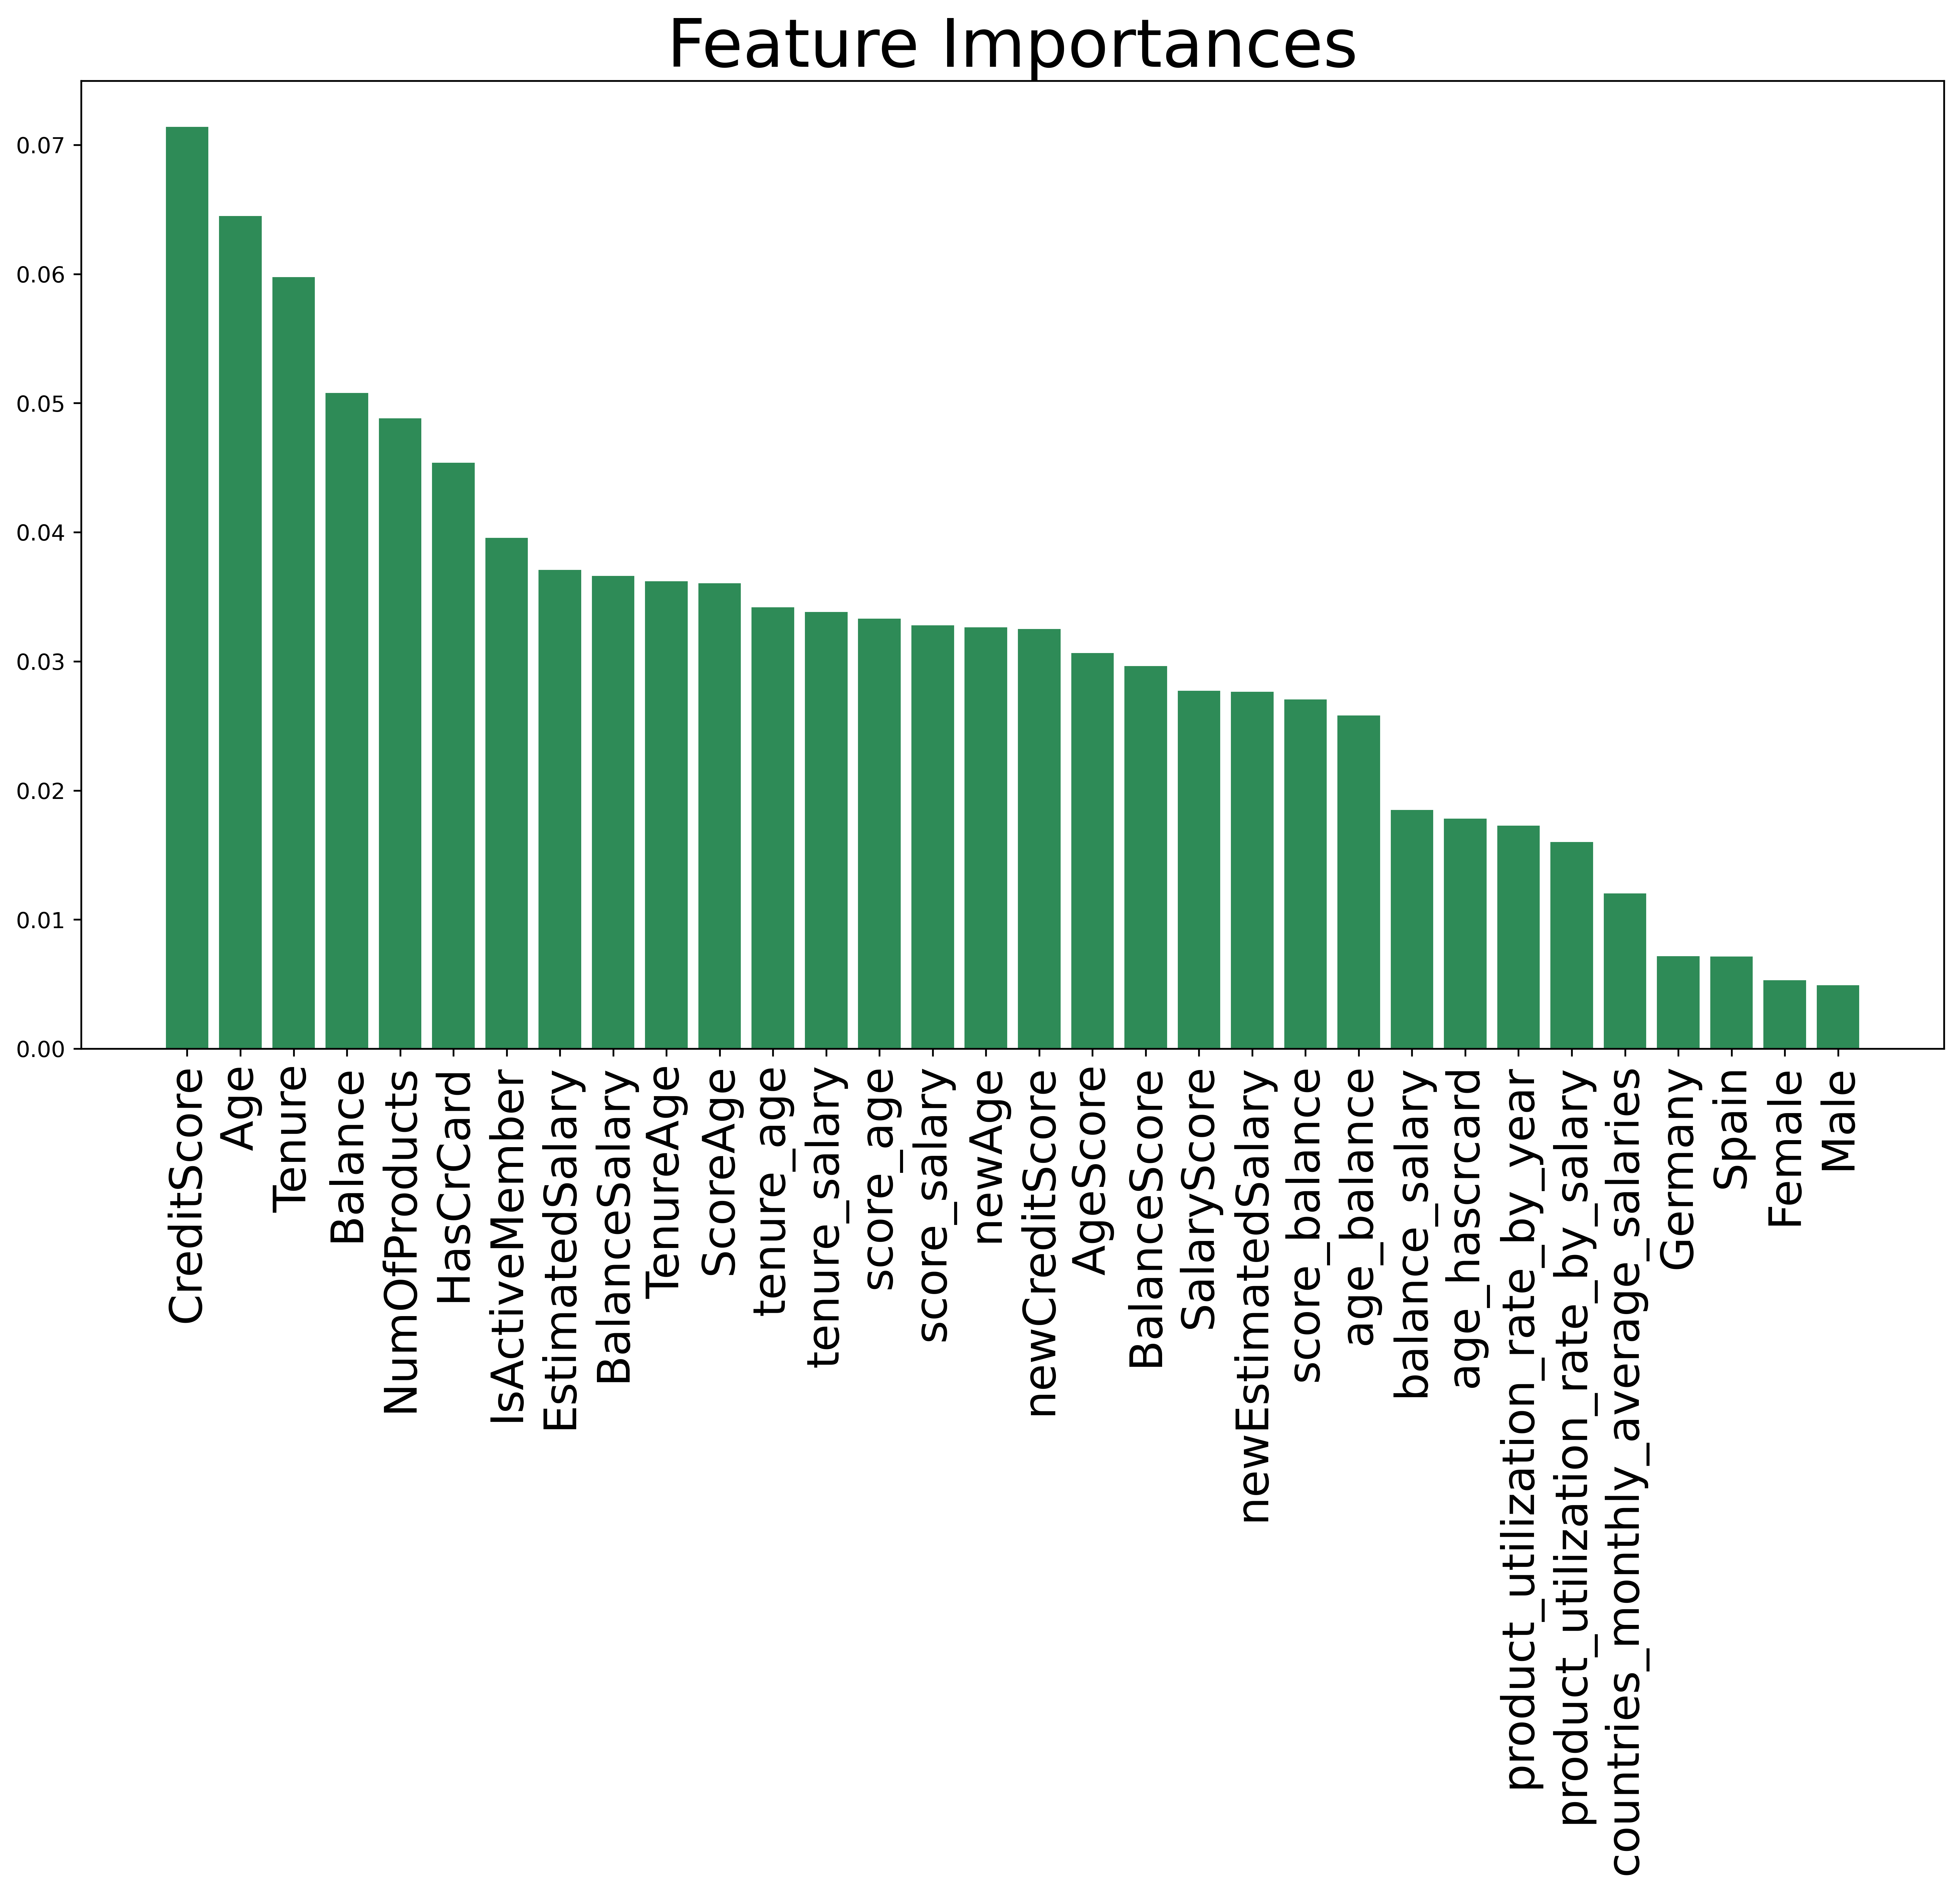

In [17]:
from sklearn.ensemble import RandomForestClassifier

# We perform training on the Random Forest model and generate the importance of the features
features_label = X.columns
forest = RandomForestClassifier (n_estimators = 10000, random_state = 0, n_jobs = -1)
forest.fit(X, Y)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]
for i in range(X.shape[1]):
    print ("%2d) %-*s %f" % (i + 1, 30, features_label[i], importances[indices[i]]))
    
# Visualization of the Feature importances
plt.figure(figsize = (15, 8), dpi = 480)
plt.title('Features Importance', fontsize = 30)
plt.bar(range(X.shape[1]), importances[indices], color = "seagreen", align = "center")
plt.xticks(range(X.shape[1]), features_label, rotation = 90, fontsize = 20)
plt.savefig('FeatureImportances_FE,S.png')
plt.show()